# Customer Churn Prediction
### Problem Statement: ### 
***Build an Artificial Neural Network (ANN) to predict whether a telecom customer is likely to leave the company (Churn Prediction) based on customer usage and support history***

**Algorithm:** Artificial Neural Network (ANN)

**Architecture:** Feedforward Neural Network / Multilayer Perceptron (FNN / MLP)

**Task:** Binary Classification

**Framework:** TensorFlow / Keras


In [1]:
# Step 1: Import Libraries
import numpy as np                  # For numerical operations and arrays
import pandas as pd                 # For data loading and manipulation
import matplotlib.pyplot as plt     # For data visualization

In [2]:
# Load the dataset CSV file into a Pandas DataFrame
df = pd.read_csv('Telco-Customer-Churn.csv')

# Display the first 5 records of the dataset
print("First 5 records:")
print(df.head())

# Display number of rows and columns in the dataset
print("\nDataset shape (rows, columns):", df.shape)

# Display the column names
print("\nColumn names:")
print(df.columns.tolist())

# Display information about the dataset (data types, non-null counts)
print("\nDataset Info:")
print(df.info())

# Display statistical summary for numerical columns
print("\nStatistical Summary:")
print(df.describe())

First 5 records:
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies    

In [3]:
# EDA
# Check Missing Values
df.isnull().sum()

df["TotalCharges"].value_counts().head()
#convert 'TotalCharges' to numeric
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [4]:
# Handle Missing values
df.dropna(inplace=True)

print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [5]:
# Check Duplicate Records
print("Duplicate rows:", df.duplicated().sum())

# If duplicates exist, remove them
df.drop_duplicates(inplace=True)

Duplicate rows: 0


In [6]:
# Prepare input features and target
# Remove customerID because it is only an identifier
df = df.drop("customerID", axis=1)

# Separate input features and target
X = df.drop("Churn", axis=1)

y = df["Churn"]
print("Target:\n",y)

print("Input shape:", X.shape)
print("Target shape:", y.shape)

Target:
 0        No
1        No
2       Yes
3        No
4       Yes
       ... 
7038     No
7039     No
7040     No
7041    Yes
7042     No
Name: Churn, Length: 7032, dtype: str
Input shape: (7032, 19)
Target shape: (7032,)


In [7]:
# Convert the target into binary values
y = y.map({
    "Yes": 1,
    "No": 0
})

print(y.value_counts())

Churn
0    5163
1    1869
Name: count, dtype: int64


In [8]:
# Convert categorical data into numerical data (One-hot encoding)
X = pd.get_dummies(
    X,
    drop_first=True,
    dtype=int
)

print(X.head())
print("Total input features:", X.shape[1])

   SeniorCitizen  tenure  MonthlyCharges  TotalCharges  gender_Male  \
0              0       1           29.85         29.85            0   
1              0      34           56.95       1889.50            1   
2              0       2           53.85        108.15            1   
3              0      45           42.30       1840.75            1   
4              0       2           70.70        151.65            0   

   Partner_Yes  Dependents_Yes  PhoneService_Yes  \
0            1               0                 0   
1            0               0                 1   
2            0               0                 1   
3            0               0                 0   
4            0               0                 1   

   MultipleLines_No phone service  MultipleLines_Yes  ...  \
0                               1                  0  ...   
1                               0                  0  ...   
2                               0                  0  ...   
3               

In [9]:
# Split training and testing data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (5625, 30)
Testing data: (1407, 30)


In [10]:
# Feature scaling - StandardScaler
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Scaled training shape:", X_train_scaled.shape)
print("Scaled testing shape:", X_test_scaled.shape)

Scaled training shape: (5625, 30)
Scaled testing shape: (1407, 30)


In [11]:
# Build the ANN architecture
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

model = Sequential([
    Input(shape=(X_train_scaled.shape[1],)),

    Dense(16, activation="relu"),

    Dense(8, activation="relu"),

    Dense(1, activation="sigmoid")
])

In [12]:
# Compile the model
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [13]:
# Display the architecture
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 16)                  │             496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 8)                   │             136 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │               9 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 641 (2.50 KB)

 Trainable params: 641 (2.50 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
# Train the ANN
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train_scaled,
    y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)
#EarlyStopping: Stops training when validation loss does not improve for 10 epochs.

Epoch 1/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7398 - loss: 0.5090 - val_accuracy: 0.7707 - val_loss: 0.4561
Epoch 2/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7804 - loss: 0.4552 - val_accuracy: 0.7991 - val_loss: 0.4248
Epoch 3/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7987 - loss: 0.4383 - val_accuracy: 0.8036 - val_loss: 0.4143
Epoch 4/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7991 - loss: 0.4300 - val_accuracy: 0.8044 - val_loss: 0.4104
Epoch 5/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7998 - loss: 0.4249 - val_accuracy: 0.8080 - val_loss: 0.4094
Epoch 6/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8007 - loss: 0.4211 - val_accuracy: 0.8116 - val_loss: 0.4085
Epoch 7/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8020 - loss: 0.4181 - val_accuracy: 0.8080 - val_loss: 0.4083
Epoch 8/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8036 - loss: 0.4156 - val_accu

In [15]:
# Predict customer churn

# Predict probabilities
y_probability = model.predict(X_test_scaled)

# Convert probabilities into binary predictions
y_pred = (y_probability >= 0.5).astype(int).flatten()

print("Predicted churn:")
print(y_pred[:10])

print("Actual churn:")
print(y_test.values[:10])

44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Predicted churn:
[0 1 0 0 0 0 0 0 1 0]
Actual churn:
[0 0 0 1 0 1 0 0 1 0]


In [16]:
# Display the comparision
results = pd.DataFrame({
    "Actual_Churn": y_test.values,
    "Predicted_Churn": y_pred,
    "Churn_Probability": y_probability.flatten()
})

results.head(10)

,Actual_Churn,Predicted_Churn,Churn_Probability
0,0,0,0.017627
1,0,1,0.605786
2,0,0,0.019376
3,1,0,0.234795
4,0,0,0.052807
5,1,0,0.255560
6,0,0,0.009879
7,0,0,0.199428
8,1,1,0.689795
9,0,0,0.024637


In [17]:
# Evaluate the model
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

# Calculate test loss and accuracy
loss, accuracy = model.evaluate(
    X_test_scaled,
    y_test,
    verbose=0
)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)
print(f"Final Test Accuracy: {accuracy * 100:.2f}%")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Test Loss: 0.4346800744533539
Test Accuracy: 0.7889125943183899
Final Test Accuracy: 78.89%

Confusion Matrix:
[[901 132]
 [165 209]]

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.87      0.86      1033
           1       0.61      0.56      0.58       374

    accuracy                           0.79      1407
   macro avg       0.73      0.72      0.72      1407
weighted avg       0.78      0.79      0.79      1407



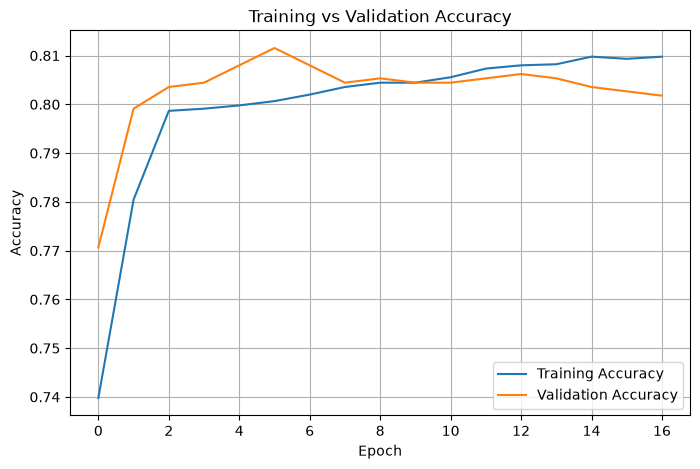

In [18]:
# Training accuracy vs Validation accuracy
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()
plt.grid(True)

plt.show()

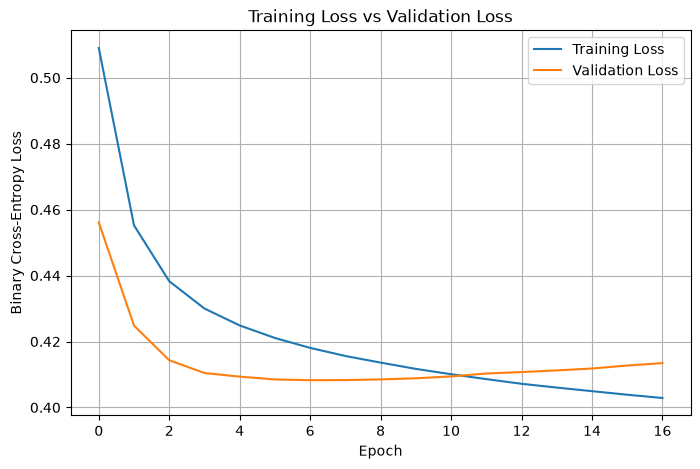

In [19]:
# Training loss vs Validation loss
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title("Training Loss vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")

plt.legend()
plt.grid(True)

plt.show()